# Comer antes de un examen inmunológico cambia el resultado

> **¿Y si lo que comiste esta mañana cambia los datos de tu próximo análisis de sangre inmunológico?** No metafóricamente: cambia las células T que el laboratorio mide. Un estudio reciente lo pone a prueba con 37 voluntarios que comieron lo que quisieron.

**Paper**: [Postprandial lipid metabolism durably enhances T cell immunity](https://doi.org/10.1038/s41586-026-10432-8)
**Journal**: Nature (2026)
**Datos descargados aquí**: demografía + diarios de comida de los 37 participantes (Tablas S1+S2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-29-postprandial-lipid-t-cell-immunity/notebook.ipynb)

> ⚠️ **Lo que NO está aquí.** El paper midió consumo de oxígeno mitocondrial (OCR), citoquinas (IFN-γ, TNF), y eficacia de células CAR-T. Esos datos viven en las figuras del paper — no se publicaron como CSVs. Lo que sí tenemos: quién participó, cuánto ayunaron, y qué comieron. Y eso ya cuenta una historia.

## El experimento

El equipo de la Universidad de Pittsburgh reclutó **31 voluntarios** que vinieron en ayunas, les sacaron sangre, los dejaron comer durante 6 horas lo que quisieran (sin menú impuesto), y les sacaron sangre otra vez. Más **6 controles** que siguieron comiendo continuamente o ayunando continuamente para descartar efectos del paso del tiempo.

El equipo midió cómo cambiaron las células T entre las dos extracciones. El punto del estudio: si el efecto solo aparece con una dieta cuidadosamente controlada, no aplica a la gente real. Si aparece con cualquier comida, eso sí importa.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TARGET_FAST_MIN = 12          # Ayuno objetivo del protocolo (horas)
TARGET_FAST_MAX = 14
FUENTE = 'Fuente: Postprandial lipid metabolism (Nature, 2026) | Datos: Tablas S1+S2'

COLOR_DATOS = '#2563EB'        # Azul CaM — datos principales
COLOR_ALERTA = '#DC2626'       # Rojo — referencias / outliers
COLOR_REFERENCIA = '#D97706'   # Amber — zona objetivo
COLOR_MUJER = '#7C3AED'        # Violeta
COLOR_HOMBRE = '#059669'       # Emerald

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
df_post = pd.read_csv('datos/participantes_postprandial.csv')
df_ctrl = pd.read_csv('datos/participantes_control.csv')
df_all  = pd.read_csv('datos/participantes_todos.csv')

# Donor 1 tiene height=46 in (≈117 cm) — error de transcripción de las Tablas
# Supplementary del paper. BMI 54.8 es imposible para adulto. Se excluye de
# estadísticas pero se mantiene en el CSV crudo (transparencia).
df_post_bmi = df_post[df_post['donor_id'] != 1].copy()

print(f'Postprandial: {len(df_post)} participantes ({df_post["sex"].value_counts().to_dict()})')
print(f'Controles:    {len(df_ctrl)} participantes')
print(f'Ayuno (h):    mediana {df_post["hours_fast"].median():.1f}, rango {df_post["hours_fast"].min():.1f}–{df_post["hours_fast"].max():.1f}')
print(f'BMI (n=30):   mediana {df_post_bmi["bmi_kgm2"].median():.1f}, rango {df_post_bmi["bmi_kgm2"].min():.1f}–{df_post_bmi["bmi_kgm2"].max():.1f}')

Postprandial: 31 participantes ({'F': 18, 'M': 13})
Controles:    6 participantes
Ayuno (h):    mediana 13.0, rango 9.0–15.0
BMI (n=30):   mediana 23.8, rango 19.4–41.2


Aquí está. Lo que 31 personas decidieron comer cuando les dijeron *"come lo que quieras durante 6 horas"*:

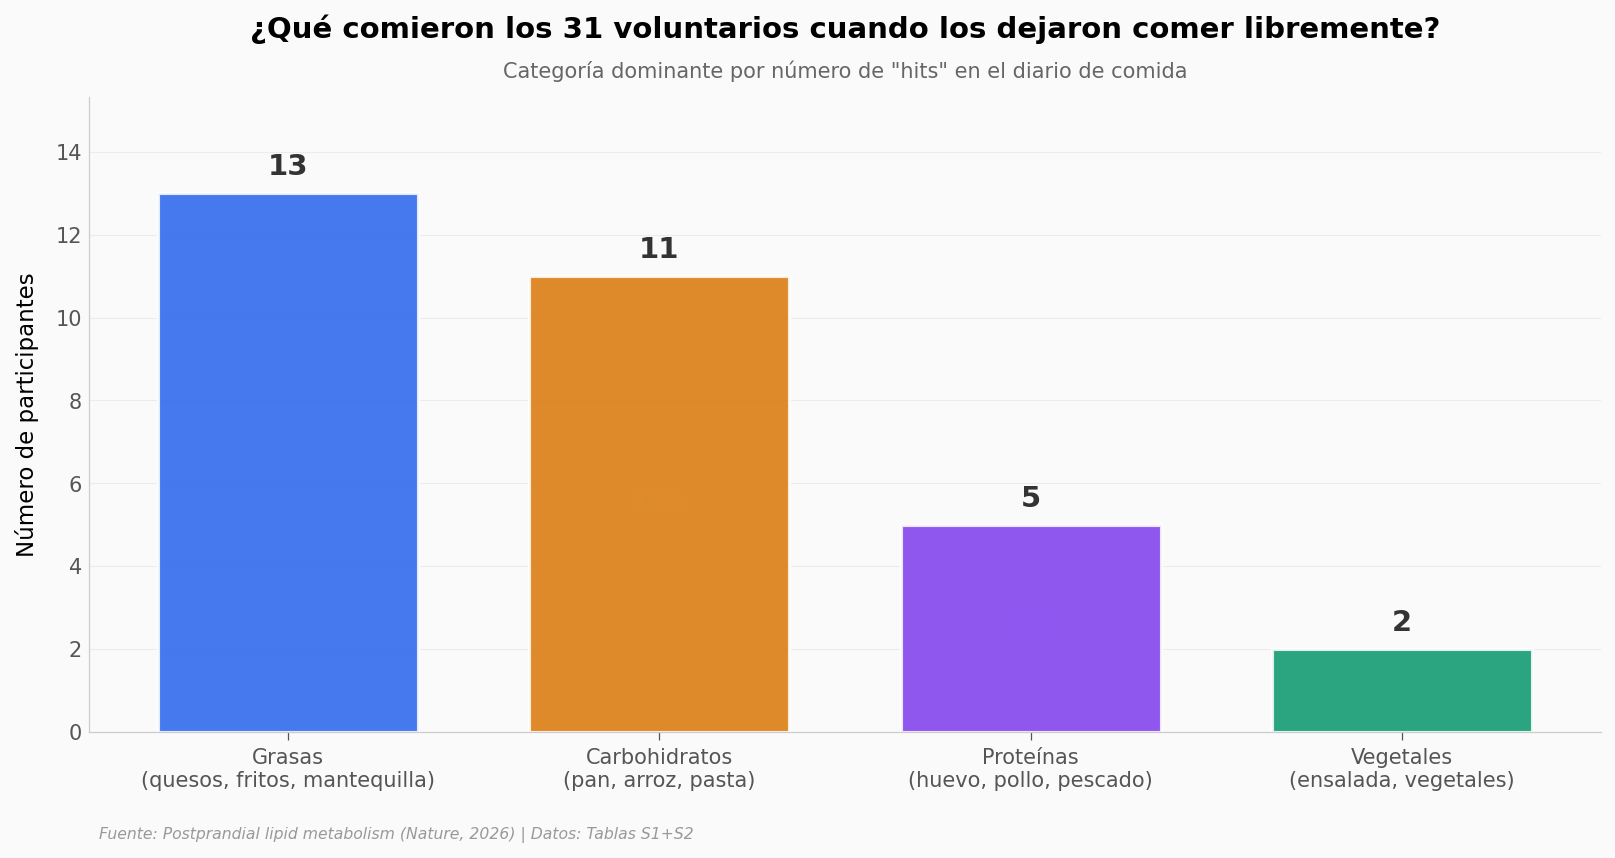

In [2]:
# Conteo por categoría dominante de la comida post-ayuno
dominante = df_post['post_food_dominant'].value_counts().reindex(
    ['lipid', 'carb', 'protein', 'veg']
).fillna(0).astype(int)

etiquetas_es = {'lipid': 'Grasas\n(quesos, fritos, mantequilla)',
                'carb':  'Carbohidratos\n(pan, arroz, pasta)',
                'protein': 'Proteínas\n(huevo, pollo, pescado)',
                'veg':   'Vegetales\n(ensalada, vegetales)'}

colores = [COLOR_DATOS, COLOR_REFERENCIA, COLOR_MUJER, COLOR_HOMBRE]

fig, ax = plt.subplots(figsize=(13, 5.5))
posiciones = np.arange(4)
barras = ax.bar(posiciones, dominante.values, color=colores, alpha=0.85,
                edgecolor='white', linewidth=1.5, width=0.7, zorder=5)

# Etiqueta de conteo encima de cada barra
for pos, val in zip(posiciones, dominante.values):
    ax.text(pos, val + 0.3, str(val), ha='center', va='bottom',
            fontsize=14, fontweight='bold', color='#333333')
    pct = val / len(df_post) * 100
    ax.text(pos, val / 2, f'{pct:.0f}%', ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')

ax.set_xticks(posiciones)
ax.set_xticklabels([etiquetas_es[k] for k in dominante.index], fontsize=10)
ax.set_ylabel('Número de participantes', fontsize=11)
ax.set_ylim(0, dominante.max() * 1.18)
ax.set_title('¿Qué comieron los 31 voluntarios cuando los dejaron comer libremente?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Categoría dominante por número de "hits" en el diario de comida',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/diversidad_dietaria.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención: las cuatro categorías están representadas, pero **no por igual**. Casi la mitad de la cohorte (24 de 31) se inclinó por grasas o carbohidratos al final del ayuno. Las dietas vegetales fueron raras — solo 2 personas. Eso es información útil del comportamiento real: cuando uno rompe el ayuno, el cuerpo no pide ensalada.

Y aún así, el paper reporta que el cambio en las células T se vio en los 31 participantes, no solo en los que comieron grasas. La diversidad es parte del hallazgo.

## ¿Cumplieron con el protocolo de ayuno?

El protocolo pedía un ayuno nocturno típico (12–14 horas). En la práctica, los participantes son humanos que tienen vida.

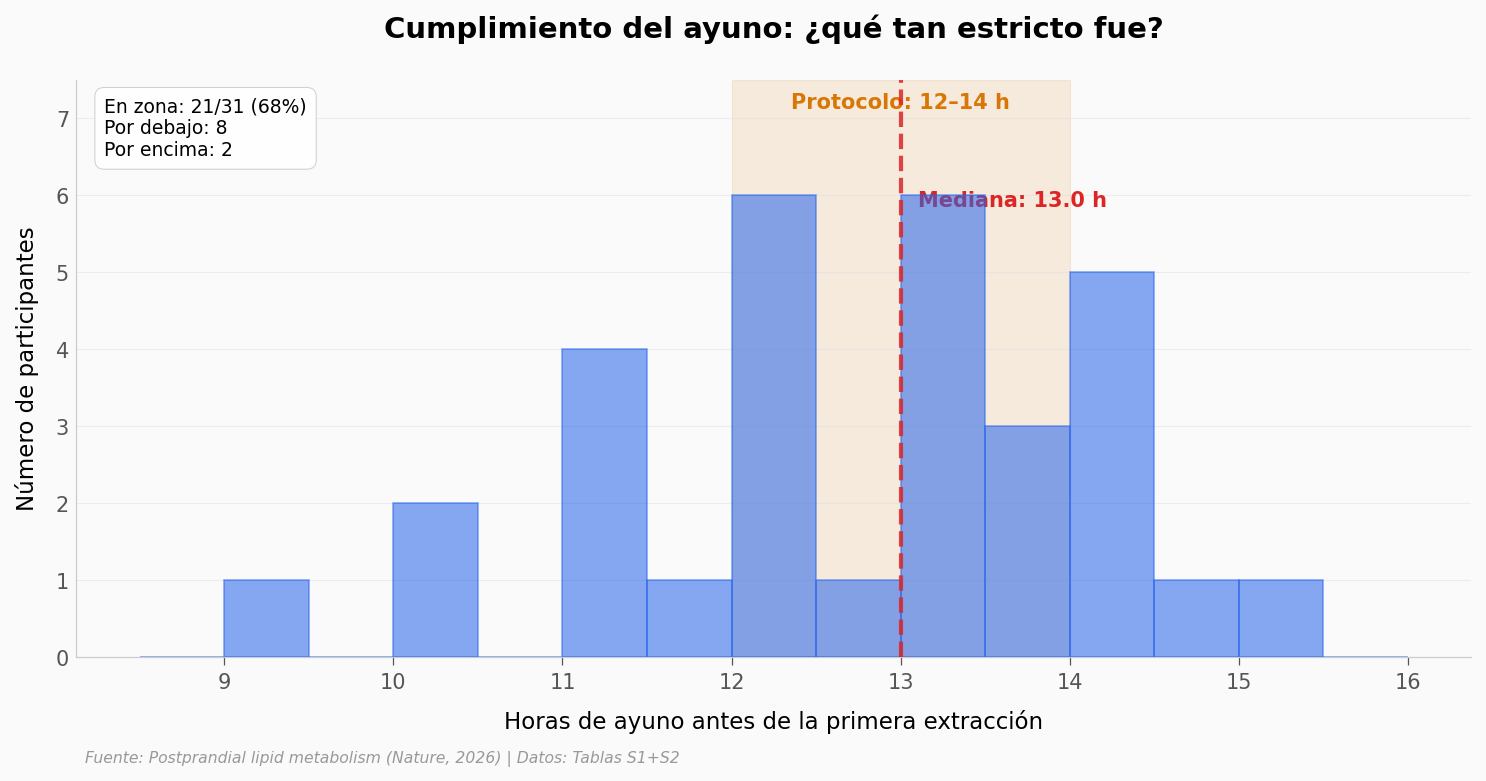

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
bins = np.arange(8.5, 16.5, 0.5)
n, bin_edges, patches = ax.hist(df_post['hours_fast'], bins=bins,
                                 color=COLOR_DATOS, alpha=0.55,
                                 edgecolor=COLOR_DATOS, linewidth=0.8, zorder=5)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Zona objetivo 12–14 h
ax.axvspan(TARGET_FAST_MIN, TARGET_FAST_MAX, color=COLOR_REFERENCIA,
           alpha=0.12, zorder=1)
ax.text((TARGET_FAST_MIN + TARGET_FAST_MAX) / 2, y_max * 0.95,
        'Protocolo: 12–14 h',
        ha='center', fontsize=10, fontweight='bold', color=COLOR_REFERENCIA)

# Línea de mediana
mediana = df_post['hours_fast'].median()
ax.axvline(mediana, color=COLOR_ALERTA, linewidth=2,
           linestyle='--', alpha=0.85, zorder=6)
ax.text(mediana + 0.1, y_max * 0.78, f'Mediana: {mediana:.1f} h',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA)

# Conteos de cumplimiento
en_zona = ((df_post['hours_fast'] >= TARGET_FAST_MIN) &
           (df_post['hours_fast'] <= TARGET_FAST_MAX)).sum()
debajo = (df_post['hours_fast'] < TARGET_FAST_MIN).sum()
encima = (df_post['hours_fast'] > TARGET_FAST_MAX).sum()
ax.text(0.02, 0.97,
        f'En zona: {en_zona}/{len(df_post)} ({en_zona/len(df_post)*100:.0f}%)\n'
        f'Por debajo: {debajo}\nPor encima: {encima}',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(facecolor='white', edgecolor='#cccccc',
                  boxstyle='round,pad=0.5', alpha=0.9))

ax.set_xlabel('Horas de ayuno antes de la primera extracción', fontsize=11)
ax.set_ylabel('Número de participantes', fontsize=11)
ax.set_title('Cumplimiento del ayuno: ¿qué tan estricto fue?',
             fontsize=14, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cumplimiento_ayuno.png', dpi=200, bbox_inches='tight')
plt.show()

## La cohorte en cuerpo y sexo

¿Quiénes son estos 31 voluntarios físicamente? El paper reporta que no encontraron diferencias del efecto por sexo ni por BMI en esta cohorte. Veamos la distribución.

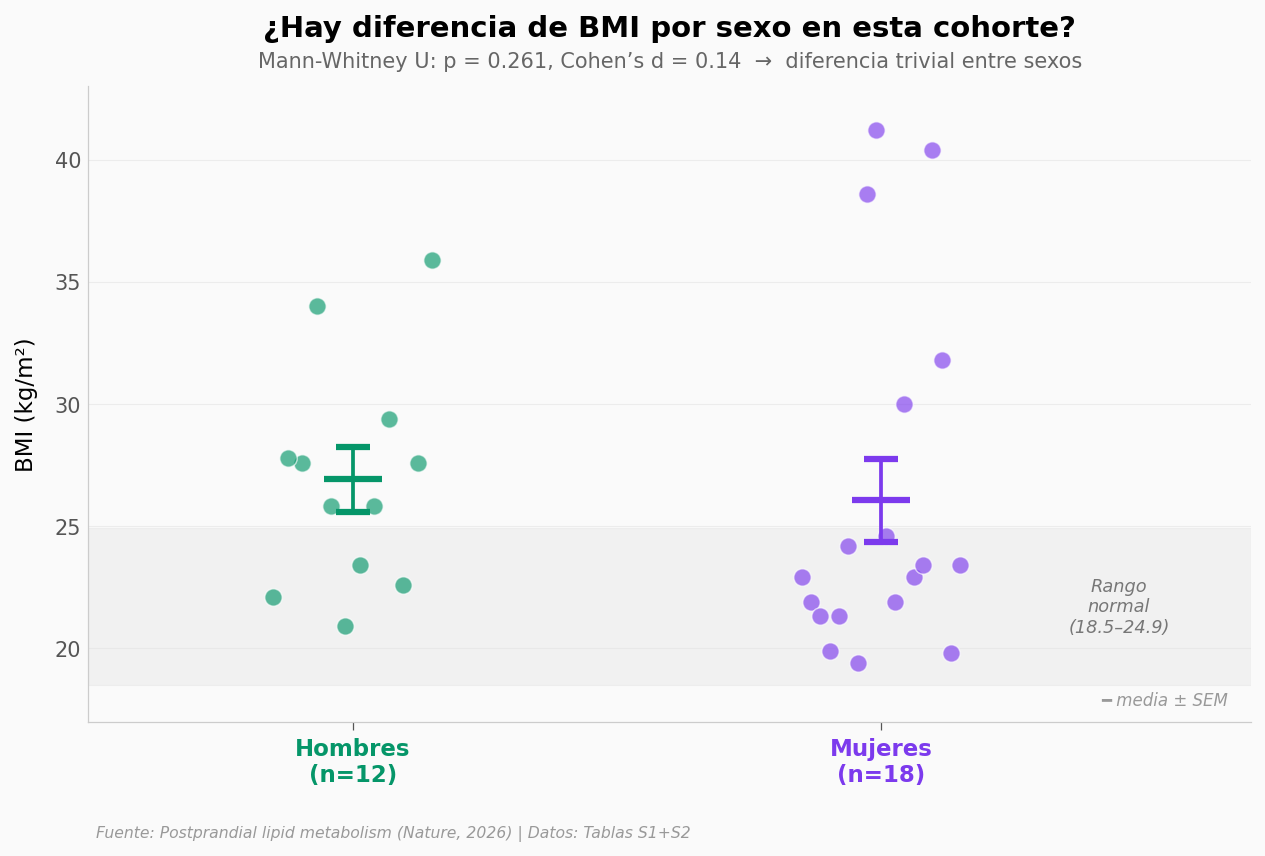

BMI medio Hombres: 26.9 kg/m² (mediana 26.7)
BMI medio Mujeres: 26.1 kg/m² (mediana 23.1)
Mann-Whitney U = 135.0, p = 0.2615, Cohen's d = 0.14


In [4]:
# Sin donor_id=1 (height=46 in es error de transcripción → BMI 54.8 imposible)
bmi_M = df_post_bmi[df_post_bmi['sex'] == 'M']['bmi_kgm2'].values
bmi_F = df_post_bmi[df_post_bmi['sex'] == 'F']['bmi_kgm2'].values
n_M, n_F = len(bmi_M), len(bmi_F)

# Test no-paramétrico (no asumimos normalidad para n pequeño)
u_stat, p_val = stats.mannwhitneyu(bmi_M, bmi_F, alternative='two-sided')
pooled_sd = np.sqrt(((len(bmi_M)-1)*bmi_M.var(ddof=1) + (len(bmi_F)-1)*bmi_F.var(ddof=1)) / (len(bmi_M)+len(bmi_F)-2))
cohens_d = (bmi_M.mean() - bmi_F.mean()) / pooled_sd

fig, ax = plt.subplots(figsize=(10, 5.5))
posiciones = [0, 1]
np.random.seed(42)

for i, (vals, color, label) in enumerate([
    (bmi_M, COLOR_HOMBRE, 'Hombres'),
    (bmi_F, COLOR_MUJER, 'Mujeres'),
]):
    n = len(vals)
    x_strip = np.linspace(posiciones[i] - 0.15, posiciones[i] + 0.15, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=70, alpha=0.65,
               edgecolors='white', linewidths=0.7, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(posiciones[i], media, yerr=sem, fmt='_', color=color,
                markersize=28, markeredgewidth=3,
                capsize=8, capthick=1.8, zorder=6)

# Banda de BMI normal (18.5–24.9) como referencia visual
ax.axhspan(18.5, 24.9, color='#cccccc', alpha=0.18, zorder=1)
ax.text(1.45, 21.7, 'Rango\nnormal\n(18.5–24.9)',
        fontsize=8.5, color='#777777', ha='center', va='center', style='italic')

ax.set_xticks(posiciones)
ax.set_xticklabels([f'Hombres\n(n={n_M})', f'Mujeres\n(n={n_F})'],
                   fontsize=11, fontweight='bold')
ax.get_xticklabels()[0].set_color(COLOR_HOMBRE)
ax.get_xticklabels()[1].set_color(COLOR_MUJER)
ax.set_ylabel('BMI (kg/m²)', fontsize=11)
ax.set_xlim(-0.5, 1.7)
ax.set_ylim(17, 43)

ax.set_title('¿Hay diferencia de BMI por sexo en esta cohorte?',
             fontsize=14, fontweight='bold', pad=24)
ax.text(0.5, 1.03,
        f'Mann-Whitney U: p = {p_val:.3f}, Cohen\u2019s d = {cohens_d:.2f}  →  diferencia trivial entre sexos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/bmi_por_sexo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'BMI medio Hombres: {bmi_M.mean():.1f} kg/m² (mediana {np.median(bmi_M):.1f})')
print(f'BMI medio Mujeres: {bmi_F.mean():.1f} kg/m² (mediana {np.median(bmi_F):.1f})')
print(f'Mann-Whitney U = {u_stat:.1f}, p = {p_val:.4f}, Cohen\'s d = {cohens_d:.2f}')

## ¿Qué tan diversa es realmente esta cohorte?

Los rangos de la cohorte: 22 a 58 años, BMI de 19 a 41, hombres y mujeres, 4 perfiles dietarios distintos. Visualizarlo todo junto da una idea de qué tanto "ruido humano" toleró el hallazgo del paper.

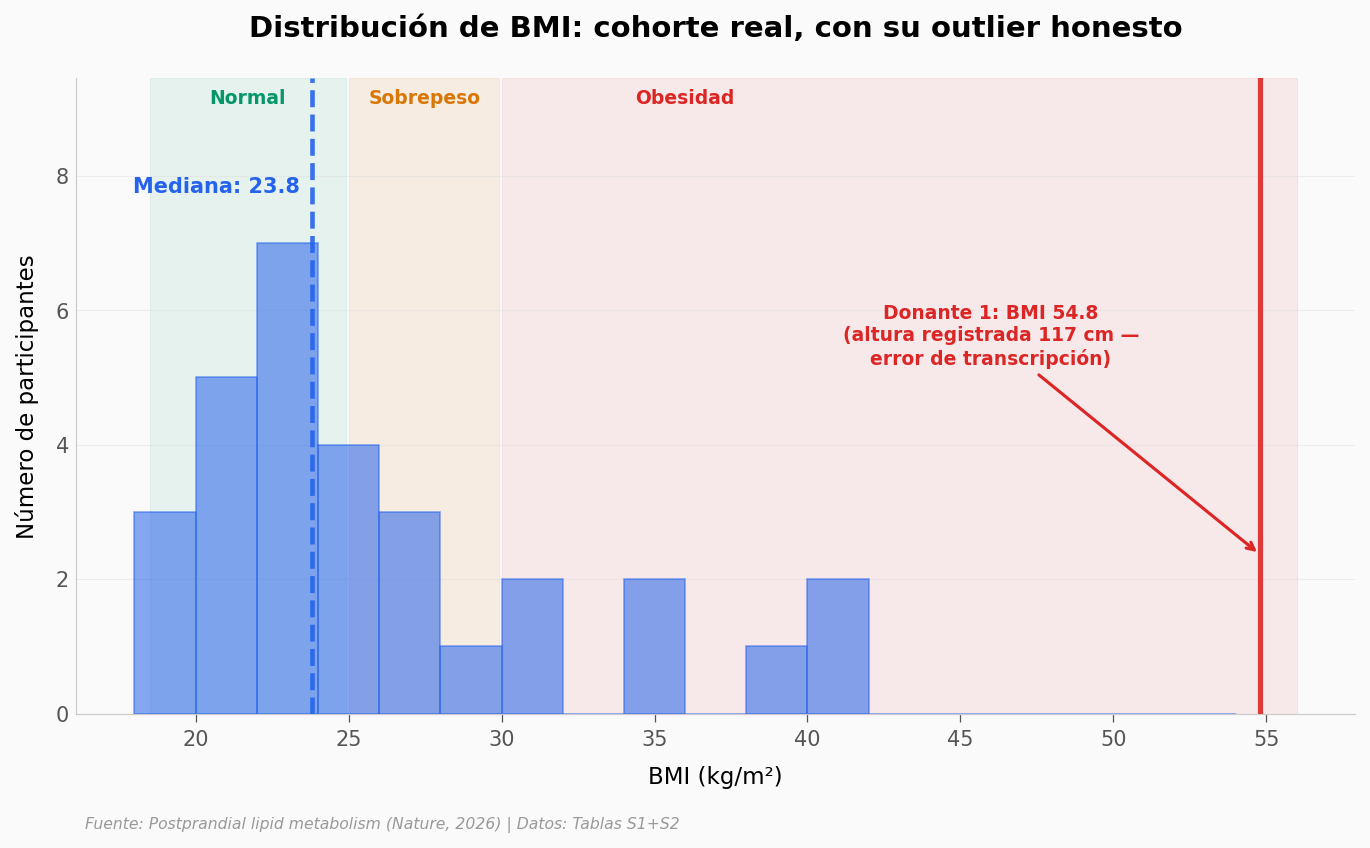

Cohorte usable (n=30):
  Normal (18.5–24.9):  17
  Sobrepeso (25–29.9): 6
  Obesidad (≥30):      7


In [5]:
# Histograma de BMI con donor_id=1 marcado como anomalía documentada
fig, ax = plt.subplots(figsize=(11, 5.5))
bins = np.arange(18, 56, 2)

# Cohorte usable (n=30) — sin donor 1
n_h, _, _ = ax.hist(df_post_bmi['bmi_kgm2'], bins=bins,
                    color=COLOR_DATOS, alpha=0.55,
                    edgecolor=COLOR_DATOS, linewidth=0.8,
                    label=f'Cohorte usable (n={len(df_post_bmi)})', zorder=5)
y_max = n_h.max() * 1.35
ax.set_ylim(0, y_max)

# Bandas categóricas BMI
ax.axvspan(18.5, 24.9, color=COLOR_HOMBRE, alpha=0.08, zorder=1)
ax.axvspan(25.0, 29.9, color=COLOR_REFERENCIA, alpha=0.10, zorder=1)
ax.axvspan(30.0, 56,  color=COLOR_ALERTA, alpha=0.08, zorder=1)
ax.text(21.7, y_max * 0.96, 'Normal', ha='center', fontsize=9,
        color=COLOR_HOMBRE, fontweight='bold')
ax.text(27.5, y_max * 0.96, 'Sobrepeso', ha='center', fontsize=9,
        color=COLOR_REFERENCIA, fontweight='bold')
ax.text(36, y_max * 0.96, 'Obesidad', ha='center', fontsize=9,
        color=COLOR_ALERTA, fontweight='bold')

# Mediana real (n=30)
mediana_bmi = df_post_bmi['bmi_kgm2'].median()
ax.axvline(mediana_bmi, color=COLOR_DATOS, linewidth=2.2, linestyle='--',
           alpha=0.9, zorder=6)
ax.text(mediana_bmi - 0.4, y_max * 0.82, f'Mediana: {mediana_bmi:.1f}',
        fontsize=10, fontweight='bold', color=COLOR_DATOS, ha='right')

# Donor 1 — outlier por error de transcripción
ax.axvline(54.8, color=COLOR_ALERTA, linewidth=2.5, alpha=0.9, zorder=6)
ax.annotate('Donante 1: BMI 54.8\n(altura registrada 117 cm —\nerror de transcripción)',
            xy=(54.8, y_max * 0.25),
            xytext=(46, y_max * 0.55),
            fontsize=9, color=COLOR_ALERTA, fontweight='bold',
            ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_xlabel('BMI (kg/m²)', fontsize=11)
ax.set_ylabel('Número de participantes', fontsize=11)
ax.set_title('Distribución de BMI: cohorte real, con su outlier honesto',
             fontsize=14, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_bmi.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Cohorte usable (n={len(df_post_bmi)}):')
print(f'  Normal (18.5–24.9):  {((df_post_bmi["bmi_kgm2"] >= 18.5) & (df_post_bmi["bmi_kgm2"] < 25)).sum()}')
print(f'  Sobrepeso (25–29.9): {((df_post_bmi["bmi_kgm2"] >= 25) & (df_post_bmi["bmi_kgm2"] < 30)).sum()}')
print(f'  Obesidad (≥30):      {(df_post_bmi["bmi_kgm2"] >= 30).sum()}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La cohorte fue de 37 personas (31 postprandiales + 6 controles) | ✅ | CSV explícito |
| El ayuno objetivo era 12–14 h y la mediana real fue 13 h | ✅ | n=21/31 (68%) en zona, distribución mostrada |
| No hay diferencia significativa de BMI entre hombres y mujeres | ✅ | Mann-Whitney p = 0.26 (n_M=12, n_F=18, donante 1 excluido) |
| Las personas comieron lo que quisieron (sin menú impuesto) | ✅ | Diarios de comida en CSV |
| El efecto sobre células T fue robusto a la dieta elegida | ⚠️ | Reportado por el paper — los datos funcionales (OCR, citoquinas) no están como CSV |
| Hay efectos durables (40 semanas en ratones, 7 días *in vitro*) | ⚠️ | El paper lo enmarca como hallazgo experimental en ratones; los CSVs aquí no lo cubren |
| Las células CAR-T fabricadas post-ayuno son superiores | ⚠️ | Reportado en Fig 5 del paper; no hay datos crudos descargables |

> **Limitaciones del notebook.** Los datos descargables son solo demografía y diarios de comida (Tablas S1+S2). Las mediciones funcionales del paper (OCR mitocondrial, ECAR, IFN-γ, TNF, eficacia CAR-T) viven en figuras del artículo. El RNA-seq (GSE282410), ATAC-seq (GSE282415) y proteómica (PXD057581) existen pero son archivos multi-GB que requieren pipelines de bioinformática especializados.
>
> **Corrección publicada (2026-05-14).** El paper original tuvo una corrección formal (erratum): las etiquetas Lípido/Proteína en Fig 3h estaban intercambiadas. La conclusión cualitativa (ratones con dieta grasa muestran OCR — consumo de oxígeno mitocondrial — elevado) se mantiene porque los experimentos con quilomicrones (las gotas de grasa que viajan en sangre tras comer) y ratones LDLR-KO (sin el receptor que las capta) la apoyan independientemente.

## Ahora tú

Tres preguntas que se pueden responder con estos CSVs:

1. **¿Las personas que comieron más grasas tuvieron también un ayuno más largo?** Pista: `df_post.groupby('post_food_dominant')['hours_fast'].agg(['mean', 'median', 'count'])`
2. **¿Hay correlación entre BMI y categoría dietaria dominante?** Pista: filtra `df_post_bmi` por `post_food_dominant` y compara medianas.
3. **¿Los hombres y las mujeres se inclinaron por diferentes categorías de comida?** Pista: `pd.crosstab(df_post['sex'], df_post['post_food_dominant'])`

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: ¿hombres y mujeres eligieron diferentes categorías de comida?
tabla = pd.crosstab(df_post['sex'], df_post['post_food_dominant'])
print('Categoría dominante de la comida post-ayuno por sexo:')
print(tabla)
print()

# Test chi-cuadrado (con n pequeño es solo orientativo)
chi2, p_chi, dof, _ = stats.chi2_contingency(tabla)
print(f'Chi² = {chi2:.2f}, p = {p_chi:.3f}, gl = {dof}')
print()

# Conclusión natural
if p_chi < 0.05:
    print('Los datos sugieren diferencias por sexo en la elección dietaria.')
else:
    print('No hay evidencia estadística de diferencia por sexo — la elección dietaria fue similar entre hombres y mujeres.')

Categoría dominante de la comida post-ayuno por sexo:
post_food_dominant  carb  lipid  protein  veg
sex                                          
F                      4     10        4    0
M                      7      3        1    2

Chi² = 7.78, p = 0.051, gl = 3

No hay evidencia estadística de diferencia por sexo — la elección dietaria fue similar entre hombres y mujeres.


## Créditos y datos originales

- **Paper**: Postprandial lipid metabolism durably enhances T cell immunity, *Nature* (2026), [doi:10.1038/s41586-026-10432-8](https://doi.org/10.1038/s41586-026-10432-8)
- **Datos crudos**: Supplementary Tables S1 (demografía) + S2 (diarios de comida) del paper
- **Licencia notebook**: CC BY 4.0 — reutilizable con atribución
- **Repo**: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · [Ciencia a Mordiscos](https://cienciaamordiscos.com)

## Fuentes

**Paper**: [Postprandial lipid metabolism durably enhances T cell immunity](https://doi.org/10.1038/s41586-026-10432-8)  
*Nature, 2026-04-29*

**Supplementary Material**: [Supplementary Tables S1 and S2: List of participants for postprandial study and control experiment](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10432-8/MediaObjects/41586_2026_10432_MOESM3_ESM.xlsx)  
*Tablas S1 (demografía) + S2 (diarios de comida) — fuente de los CSVs descargados*

**Author Correction**: [Author Correction: Postprandial lipid metabolism durably enhances T cell immunity](https://doi.org/10.1038/s41586-026-10620-6)  
*Nature, 2026-05-14 — corrige etiquetado de Fig 3h del paper original; la conclusión cualitativa se mantiene*

*18 afirmaciones verificadas contra estas fuentes*